In [23]:
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from collections import defaultdict
from sklearn.metrics import f1_score

NUM_CONT_FEATS = 13

def compute_normalization_stats(train_sequences, num_cont_feats=NUM_CONT_FEATS):
    """
    train_sequences: список np.ndarray [T, F]
    Считаем mean/std только по первым num_cont_feats признакам на всём трейн-сете.
    """
    all_rows = []
    for seq in train_sequences:
        base = seq[:, :num_cont_feats]  # только continuous
        all_rows.append(base.reshape(-1, num_cont_feats))
    all_rows = np.concatenate(all_rows, axis=0)

    mean = all_rows.mean(axis=0)
    std = all_rows.std(axis=0)
    std[std < 1e-6] = 1.0 
    return mean, std


def apply_normalization(sequences, mean, std, num_cont_feats=NUM_CONT_FEATS):
    """
    Применяем (x - mean) / std к первым num_cont_feats фичам.
    Остальное (бинарные и one-hot) не трогаем.
    """
    normed = []
    for seq in sequences:
        seq = seq.copy()
        seq[:, :num_cont_feats] = (seq[:, :num_cont_feats] - mean) / std
        normed.append(seq)
    return normed

def build_encoders(pbp: pd.DataFrame, rare_frac: float = 0.0001) -> Dict[str, Dict[str, int]]:
    """
    rare_frac=0.0001 => 0.01% (1e-4) от всех событий в TRAIN
    Всё редкое и всё неизвестное в OTHER.
    """
    encoders: Dict[str, Dict[str, int]] = {}

    et = pbp["event_type"].astype(str).str.upper()
    st = pbp["secondary_type"].astype("string")

    combined = []
    for e, s in zip(et, st):
        if pd.isna(s) or s == "":
            combined.append(e)
        else:
            combined.append(f"{e}_{str(s).upper()}")

    vc = pd.Series(combined).value_counts()
    total = vc.sum()

    # оставляем только частые категории, редкие идут в OTHER
    keep = vc[(vc / total) > rare_frac].index.tolist()

    # создаём маппинг: OTHER всегда 0
    mapping = {"OTHER": 0}
    for i, ct in enumerate(sorted(keep), start=1):
        if ct != "OTHER":
            mapping[ct] = i

    encoders["event_type_combined"] = mapping
    return encoders



#2 Построение выборок по минутам периода
def build_game_sequences(
    pbp: pd.DataFrame,
    encoders: Dict[str, Dict[str, int]],
    min_events_per_game: int = 50,
    window_size: int = 50,
    max_period: int = 3,  # берём только 1–3 периоды
) -> Tuple[List[np.ndarray], List[int], List[dict]]:
    """
    Делаем выборки для обучения:

    Каждая выборка = 50 последних событий перед минутной отметкой в периоде.
    Лейбл = результат периода: 1, если home ведёт после конца периода, иначе 0.

    Возвращает:
      - X_list: список np.ndarray[window_size, F]
      - y_list: список int (0/1)
      - meta_list: список словарей с метой:
            { "game_id": ..., "period": ..., "minute_in_period": ..., "evant_time": ... }
    """

    required_cols = [
        "game_id", "event_type", "period", "game_seconds", "period_seconds",
        "home_score", "away_score",
        "event_team_type",
        "x_fixed", "y_fixed",
        "shot_distance", "shot_angle",
        "home_skaters", "away_skaters",
        "extra_attacker",
        "secondary_type",
    ]
    missing = [c for c in required_cols if c not in pbp.columns]
    if missing:
        raise ValueError(f"Missing required columns in pbp: {missing}")

    # сортируем внутри игры по времени
    pbp_sorted = pbp.sort_values(["game_id", "game_seconds"]).reset_index(drop=True)

    X_list: List[np.ndarray] = []
    y_list: List[int] = []
    meta_list: List[dict] = []

    event_type_to_idx = encoders["event_type_combined"]
    other_idx = event_type_to_idx["OTHER"]

    for game_id, g in pbp_sorted.groupby("game_id", sort=False):
        if len(g) < max(min_events_per_game, window_size):
            continue

        g = g.reset_index(drop=True)
        N = len(g)

        # общие массивы по игре
        game_seconds = g["period_seconds"].astype(float).values
        t_norm = game_seconds / 1200.0

        period_arr = g["period"].astype(int).values

        home_score_all = g["home_score"].astype(float).values
        away_score_all = g["away_score"].astype(float).values
        score_diff_all = home_score_all - away_score_all

        home_skaters_all = g["home_skaters"].astype(float).fillna(0.0).values
        away_skaters_all = g["away_skaters"].astype(float).fillna(0.0).values

        extra_attacker_all = g["extra_attacker"].astype(float).fillna(0.0).values

        is_home_event_all = g["event_team_type"].eq("home").fillna(False).astype(float).values
        is_away_event_all = g["event_team_type"].eq("away").fillna(False).astype(float).values

        x_fixed_all = g["x_fixed"].astype(float).fillna(0.0).values
        y_fixed_all = g["y_fixed"].astype(float).fillna(0.0).values
        shot_distance_all = g["shot_distance"].astype(float).fillna(0.0).values
        shot_angle_all = g["shot_angle"].astype(float).fillna(0.0).values

        event_type_all = g["event_type"].astype(str).str.upper().values

        team_type_all = (
            g["event_team_type"]
            .fillna("unknown")   
            .astype(str)
            .str.lower()
            .values              
        )

        cont_all = np.stack(
            [
                t_norm,
                home_score_all,
                away_score_all,
                score_diff_all,
                home_skaters_all,
                away_skaters_all,
                x_fixed_all,
                y_fixed_all,
                shot_distance_all,
                shot_angle_all,
            ],
            axis=1,
        ).astype(np.float32)

        # бинарные фичи
        binary_all = np.stack(
            [
                extra_attacker_all,
                is_home_event_all,
                is_away_event_all,
            ],
            axis=1,
        ).astype(np.float32)

        # period -> one-hot
        num_periods = max_period
        period_ohe_all = np.zeros((N, num_periods), dtype=np.float32)
        for i, p in enumerate(period_arr):
            if 1 <= p <= num_periods:
                period_ohe_all[i, p - 1] = 1.0
        
        et = g["event_type"].astype(str).str.upper().values
        st = g["secondary_type"].astype("string").values

        combined = []
        for e, s in zip(et, st):
            if pd.isna(s) or s == "":
                combined.append(e)
            else:
                combined.append(f"{e}_{str(s).upper()}")

        num_types = len(event_type_to_idx)
        type_ohe_all = np.zeros((N, len(event_type_to_idx)), dtype=np.float32)
        for i, ct in enumerate(combined):
            j = event_type_to_idx.get(ct, other_idx)   # <--- ключевая строка
            type_ohe_all[i, j] = 1.0
            
        home_start_score_all = np.zeros(N, dtype=np.float32)
        away_start_score_all = np.zeros(N, dtype=np.float32)
        
        for pp in range(1, max_period + 1):
            mask_pp = (period_arr == pp)
            if not mask_pp.any():
                continue
            idxs_pp = np.where(mask_pp)[0]
            first = idxs_pp[0]
        
            if first > 0:
                hb = float(home_score_all[first - 1])
                ab = float(away_score_all[first - 1])
            else:
                hb = 0.0
                ab = 0.0
        
            home_start_score_all[idxs_pp] = hb
            away_start_score_all[idxs_pp] = ab
        
        home_in_own_period_all = (home_score_all - home_start_score_all).astype(np.float32)
        away_in_own_period_all = (away_score_all - away_start_score_all).astype(np.float32)
        diff_in_own_period_all = (home_in_own_period_all - away_in_own_period_all).astype(np.float32)
        
        # по периодам
        for p in range(1, max_period + 1):
            period_mask = (period_arr == p)
            if not period_mask.any():
                continue

            idxs_p = np.where(period_mask)[0]
            times_p = game_seconds[idxs_p]

            first_idx = idxs_p[0]
            if first_idx > 0:
                home_before = home_score_all[first_idx - 1]
                away_before = away_score_all[first_idx - 1]
            else:
                home_before = 0.0
                away_before = 0.0

            
            # minute_in_period = 1..20
            for minute_in_period in range(1, 21):
                threshold = 60 * (minute_in_period-1)

                # ищем первое событие этого периода, у которого game_seconds >= threshold
                pos_in_p = np.searchsorted(times_p, threshold, side="left")
                if pos_in_p >= len(times_p):
                    continue

                idx_event = idxs_p[pos_in_p] 
                if idx_event < window_size - 1:
                    # недостаточно 50 предыдущих событий
                    continue

                future_idxs = idxs_p[idxs_p > idx_event]

                label = 2  # по умолчанию: голов больше не будет
                for fi in future_idxs:
                    if event_type_all[fi] == "GOAL":
                        team = team_type_all[fi]
                        if team == "home":
                            label = 0  # следующая забьёт домашняя
                            break
                        elif team == "away":
                            label = 1  # следующая забьёт гостевая
                            break
                        else:
                            # goal с непонятной командой — игнорируем и смотрим дальше
                            continue
                
                # окно из 50 событий 
                start_idx = idx_event - window_size + 1
                end_idx = idx_event + 1  # срез до end_idx не включительно
                window_idx = np.arange(start_idx, end_idx)
                
                cont = cont_all[window_idx].astype(np.float32)
                extra = np.stack(
                    [
                        home_in_own_period_all[window_idx],
                        away_in_own_period_all[window_idx],
                        diff_in_own_period_all[window_idx],
                    ],
                    axis=1
                ).astype(np.float32)
                
                cont = np.concatenate([cont, extra], axis=1)       # [T, 13]
                
                binary = binary_all[window_idx]
                period_ohe = period_ohe_all[window_idx]
                type_ohe = type_ohe_all[window_idx]

                feat_mat = np.concatenate(
                    [cont, binary, period_ohe, type_ohe],
                    axis=1
                )  

                X_list.append(feat_mat)
                y_list.append(label)
                meta_list.append(
                    {
                        "game_id": game_id,
                        "period": int(p),
                        "minute_in_period": int(minute_in_period),
                        "event_time": float(game_seconds[idx_event]),
                    }
                )

    y_arr = np.array(y_list, dtype=float)
    print("y NaN:", np.isnan(y_arr).sum())
    print("y уникальные значения:", np.unique(y_arr))

    return X_list, y_list, meta_list

# Dataset + collate_fn для PyTorch

class HockeySeqDataset(Dataset):
    """
    один объект = одна выборка (50 событий).
    x: [T, F], y: 0/1 (home ведёт после периода), meta: словарь с метой.
    """
    def __init__(self, sequences: List[np.ndarray], labels: List[int], metas: List[dict]):
        assert len(sequences) == len(labels) == len(metas)
        self.sequences = sequences
        self.labels = labels
        self.metas = metas

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.sequences[idx])  # [T, F]
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        meta = self.metas[idx]
        return x, y, meta


def collate_pad(batch):
    """
    Пакуем батч в общий тензор [B, T_max, F] + маска [B, T_max]
    и прокидываем meta как список словарей.
    """
    xs, ys, metas = zip(*batch)  # добавили metas
    lengths = [x.size(0) for x in xs]
    F = xs[0].size(1)
    B = len(xs)
    T_max = max(lengths)

    padded = xs[0].new_zeros((B, T_max, F))
    mask = torch.zeros((B, T_max), dtype=torch.bool)  # True на реальных шагах

    for i, x in enumerate(xs):
        L = x.size(0)
        padded[i, :L] = x
        mask[i, :L] = True

    y = torch.stack(ys)
    metas = list(metas)  # просто список словарей
    return padded, y, mask, metas


In [24]:
batch_size = 64
num_epochs = 20
lr = 1e-3

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

# Загрузка данных
df1 = pd.read_csv("data/play_by_play_2021_22.csv.gz", encoding="latin1")
df2 = pd.read_csv("data/play_by_play_2022_23.csv.gz", encoding="latin1")
df3 = pd.read_csv("data/play_by_play_2023_24.csv.gz", encoding="latin1")
df = pd.concat([df1, df2, df3], ignore_index=True)

del df1
del df2
del df3
# убираем мелкие замены
df_model = df[
    (df["event_type"] != "CHANGE")
    | ((df["event_type"] == "CHANGE") & (df["secondary_type"].fillna("") == "Line change"))
].copy()


# хронологический сплит: уникальные game_id, отсортированные по дате игры
game_dates = df_model.groupby("game_id")["game_date"].first()
unique_game_ids = game_dates.sort_values().index.tolist()

n_games = len(unique_game_ids)
n_train_games = int(0.8 * n_games)

train_game_ids = set(unique_game_ids[:n_train_games])
val_game_ids   = set(unique_game_ids[n_train_games:])

df_train = df_model[df_model["game_id"].isin(train_game_ids)].copy()
df_val   = df_model[df_model["game_id"].isin(val_game_ids)].copy()

# --- 2) энкодеры ТОЛЬКО по train ---
# (тут предполагается, что ты заменил build_encoders на версию с OTHER и rare_frac)
encoders = build_encoders(df_train, rare_frac=0.0001)  # 0.01%

# --- 3) строим последовательности отдельно ---
X_train_raw, y_train, meta_train = build_game_sequences(
    df_train, encoders,
    min_events_per_game=50,
    window_size=50,
    max_period=3
)

X_val_raw, y_val, meta_val = build_game_sequences(
    df_val, encoders,
    min_events_per_game=50,
    window_size=50,
    max_period=3
)

# можно чистить память
del df
del df_model
del df_train
del df_val

# --- 4) нормализация только по train ---
mean, std = compute_normalization_stats(X_train_raw)

X_train = apply_normalization(X_train_raw, mean, std)
X_val   = apply_normalization(X_val_raw,   mean, std)

# --- 5) датасеты/лоадеры ---
train_ds = HockeySeqDataset(X_train, y_train, meta_train)
val_ds   = HockeySeqDataset(X_val,   y_val,   meta_val)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_pad)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_pad)

Device: mps


/var/folders/0l/xfft8w6n0b3_jk_3yp0h5dp80000gn/T/ipykernel_6563/2559008341.py:13: DtypeWarning: Columns (49,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("data/play_by_play_2021_22.csv.gz", encoding="latin1")
/var/folders/0l/xfft8w6n0b3_jk_3yp0h5dp80000gn/T/ipykernel_6563/2559008341.py:14: DtypeWarning: Columns (48,49,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("data/play_by_play_2022_23.csv.gz", encoding="latin1")
/var/folders/0l/xfft8w6n0b3_jk_3yp0h5dp80000gn/T/ipykernel_6563/2559008341.py:15: DtypeWarning: Columns (42,43,49,50,120,136) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("data/play_by_play_2023_24.csv.gz", encoding="latin1")


y NaN: 0
y уникальные значения: [0. 1. 2.]
y NaN: 0
y уникальные значения: [0. 1. 2.]


In [35]:
input_dim = train_ds[0][0].shape[1]

model_type = "lstm"   # варианты: "transformer", "lstm", "tcn"

if model_type == "transformer":
    model = TransformerOutcomeModel(
        input_dim=input_dim,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.3,
        num_classes=3,
    )
elif model_type == "lstm":
    model = LSTMOutcomeModel(
        input_dim=input_dim,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3,
        num_classes=3,
    )
elif model_type == "tcn":
    model = TCNOutcomeModel(
        input_dim=input_dim,
        num_channels=[128, 128, 128, 128],
        kernel_size=3,
        dropout=0.3,
        num_classes=3,
    )
else:
    raise ValueError(f"Unknown model_type: {model_type}")

model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',  
    factor=0.5,  
    patience=2
)

best_val_loss = float("inf")
best_state = None  # в памяти
best_epoch = -1
PATIENCE = 6
epochs_no_improve = 0

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, device)
    print(f"Epoch {epoch}: "
          f"train_loss={train_loss:.4f} "
          f"val_loss={val_loss:.4f} "
          f"val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        print(f"saved best model at epoch {best_epoch} (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1


    scheduler.step(val_loss)

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping: no val_loss improvement for {PATIENCE} epochs")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print(f"Loaded best model from epoch {best_epoch} with val_loss={best_val_loss:.4f}")


Epoch 1: train_loss=0.9602 val_loss=0.9559 val_acc=0.5236
saved best model at epoch 1 (val_loss=0.9559)
Epoch 2: train_loss=0.9455 val_loss=0.9539 val_acc=0.5243
saved best model at epoch 2 (val_loss=0.9539)
Epoch 3: train_loss=0.9418 val_loss=0.9575 val_acc=0.5117
Epoch 4: train_loss=0.9391 val_loss=0.9635 val_acc=0.5055
Epoch 5: train_loss=0.9352 val_loss=0.9624 val_acc=0.5155
Epoch 6: train_loss=0.9231 val_loss=0.9743 val_acc=0.5095
Epoch 7: train_loss=0.9116 val_loss=0.9846 val_acc=0.5053
Epoch 8: train_loss=0.8977 val_loss=1.0135 val_acc=0.4977
Early stopping: no val_loss improvement for 6 epochs
Loaded best model from epoch 2 with val_loss=0.9539


In [36]:
evaluate_by_minute_and_period(model, val_loader, device)


=== Period 1 ===
Minute  5: acc=0.375 macroF1=0.182 auc=0.719 (n=8) | pred 0:88% 1:12% 2:0%
Minute  6: acc=0.327 macroF1=0.252 auc=0.490 (n=55) | pred 0:78% 1:22% 2:0%
Minute  7: acc=0.329 macroF1=0.264 auc=0.490 (n=170) | pred 0:75% 1:25% 2:1%
Minute  8: acc=0.386 macroF1=0.355 auc=0.553 (n=350) | pred 0:63% 1:23% 2:14%
Minute  9: acc=0.314 macroF1=0.283 auc=0.495 (n=573) | pred 0:38% 1:11% 2:51%
Minute 10: acc=0.353 macroF1=0.238 auc=0.475 (n=716) | pred 0:11% 1:4% 2:84%
Minute 11: acc=0.414 macroF1=0.226 auc=0.526 (n=782) | pred 0:2% 1:2% 2:96%
Minute 12: acc=0.455 macroF1=0.220 auc=0.508 (n=820) | pred 0:1% 1:0% 2:99%
Minute 13: acc=0.494 macroF1=0.220 auc=0.527 (n=830) | pred 0:0% 1:0% 2:100%
Minute 14: acc=0.529 macroF1=0.231 auc=0.492 (n=835) | pred 0:0% 1:0% 2:100%
Minute 15: acc=0.574 macroF1=0.243 auc=0.507 (n=836) | pred 0:0% 1:0% 2:100%
Minute 16: acc=0.645 macroF1=0.261 auc=0.484 (n=837) | pred 0:0% 1:0% 2:100%
Minute 17: acc=0.706 macroF1=0.276 auc=0.539 (n=837) | pred 0

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

all_logits = []
all_targets = []

with torch.no_grad():
    for x, y, mask, metas in val_loader:
        x = x.to(device)
        mask = mask.to(device)
        logits = model(x, mask)          # [B, 3]
        all_logits.append(logits.cpu())
        all_targets.append(y.cpu())

logits = torch.cat(all_logits, dim=0)    # [N, 3]
targets = torch.cat(all_targets, dim=0)  # [N]

probs = torch.softmax(logits, dim=1).numpy()  # [N, 3]
y_true = targets.numpy()
preds = probs.argmax(axis=1)


In [41]:
unique, counts = np.unique(preds, return_counts=True)
print("Predicted class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"class {cls}: {cnt} ({cnt / len(preds):.3f})")


Predicted class distribution:
class 0: 15429 (0.354)
class 1: 5787 (0.133)
class 2: 22424 (0.514)


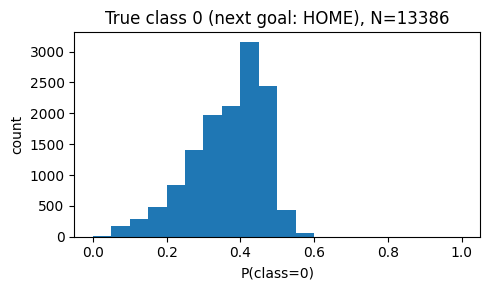

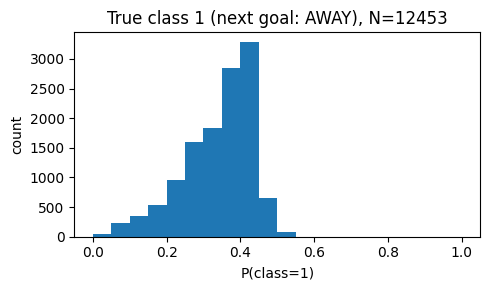

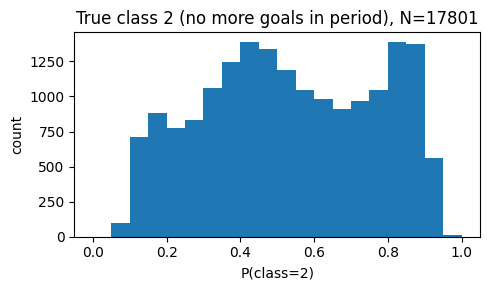

In [42]:
class_names = {
    0: "next goal: HOME",
    1: "next goal: AWAY",
    2: "no more goals in period"
}

for k in [0, 1, 2]:
    mask_k = (y_true == k)
    if mask_k.sum() == 0:
        print(f"\nNo samples with true class {k}")
        continue

    probs_k = probs[mask_k, k]  # вероятность правильного класса на этих примерах

    plt.figure(figsize=(5,3))
    plt.hist(probs_k, bins=20, range=(0, 1))
    plt.title(f"True class {k} ({class_names[k]}), N={mask_k.sum()}")
    plt.xlabel(f"P(class={k})")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


In [25]:
class LSTMOutcomeModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 num_layers: int = 2, dropout: float = 0.2,
                 num_classes: int = 3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        out, (h_n, c_n) = self.lstm(x)
        last_indices = (mask.sum(dim=1) - 1).clamp(min=0)
        batch_idx = torch.arange(x.size(0), device=x.device)
        last_hidden = out[batch_idx, last_indices]
        logits = self.fc(self.dropout(last_hidden))  # [B, num_classes]
        return logits


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, d_model]
        T = x.size(1)
        x = x + self.pe[:, :T]
        return x


class TransformerOutcomeModel(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int = 128,
        nhead: int = 4,
        num_layers: int = 3,
        dim_feedforward: int = 256,
        dropout: float = 0.2,
        num_classes: int = 3,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        src_key_padding_mask = ~mask
        enc_out = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        # enc_out: [B, T, d_model]
        # mask:    [B, T]  (True = реальный шаг)
        
        mask_float = mask.float()                          # [B, T]
        enc_out_masked = enc_out * mask_float.unsqueeze(-1)  # [B, T, d_model]
        
        sum_vec = enc_out_masked.sum(dim=1)                # [B, d_model]
        len_vec = mask_float.sum(dim=1).clamp(min=1.0)     # [B]
        
        pooled = sum_vec / len_vec.unsqueeze(-1)           # [B, d_model]
        
        logits = self.fc(self.dropout(pooled))             # [B, num_classes]
        return logits

class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, L + padding]
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    """
    Один TCN-блок: два dilated Conv1d + residual + dropout.
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float
    ):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # residual-путь 
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels
            else None
        )
        self.out_relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C_in, T]
        """
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.out_relu(out + res)   # residual + nonlinearity


class TCNOutcomeModel(nn.Module):
    """
    TCN-модель: стек TemporalBlock'ов + глобальный пуллинг по времени.
    Вход: x [B, T, F], mask [B, T]
    Выход: logits [B, num_classes]
    """
    def __init__(
        self,
        input_dim: int,
        num_channels: List[int] = None,
        kernel_size: int = 3,
        dropout: float = 0.3,
        num_classes: int = 3,
    ):
        super().__init__()
        if num_channels is None:
            num_channels = [128, 128, 128]

        layers = []
        in_ch = input_dim  
        dilation = 1
        for out_ch in num_channels:
            layers.append(
                TemporalBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            in_ch = out_ch
            dilation *= 2  

        self.network = nn.Sequential(*layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_channels[-1], num_classes)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, F]
        mask: [B, T] (True на реальных шагах)
        """
        # Conv1d ожидает [B, C, L] => C = F, L = T
        x = x.transpose(1, 2)  # [B, F, T]

        out = self.network(x)  # [B, C, T]

        # mask: [B, T], out: [B, C, T]
        mask_float = mask.float().unsqueeze(1)          # [B, 1, T]

        # заменяем паддинговые позиции на -inf, чтобы max их игнорировал
        neg_inf = torch.finfo(out.dtype).min
        out_masked = out.masked_fill(mask_float == 0, neg_inf)  # [B, C, T]

        # max-pooling по времени
        pooled, _ = out_masked.max(dim=2)               # [B, C]

        logits = self.fc(self.dropout(pooled))          # [B, num_classes]
        return logits

# Обучение и валидация

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> float:
    model.train()
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    for x, y, mask, metas in loader:
        x = x.to(device)
        y = y.to(device)         
        mask = mask.to(device)
        optimizer.zero_grad()
        logits = model(x, mask)   # [B, 3]
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> Tuple[float, float]:
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y, mask, metas in loader:
        x = x.to(device)
        y = y.to(device)         # long
        mask = mask.to(device)
        logits = model(x, mask)  # [B, 3]
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)  # [B]
        correct += (preds.cpu() == y.cpu()).sum().item()
        total += x.size(0)
    return total_loss / len(loader.dataset), correct / max(total, 1)


@torch.no_grad()
def evaluate_by_minute_and_period(model, loader, device):
    model.eval()
    bucket = defaultdict(lambda: {"y": [], "p": [], "pred_counts": None})

    for x, y, mask, metas in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        logits = model(x, mask)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_true = y.cpu().numpy()

        C = logits.size(1)
        for p_hat, yt, meta in zip(preds, y_true, metas):
            key = (int(meta["period"]), int(meta["minute_in_period"]))
            if bucket[key]["pred_counts"] is None:
                bucket[key]["pred_counts"] = np.zeros(C, dtype=np.int64)
            bucket[key]["y"].append(int(yt))
            bucket[key]["p"].append(int(p_hat))
            bucket[key]["pred_counts"][p_hat] += 1

    for p in sorted({k[0] for k in bucket.keys()}):
        print(f"\n=== Period {p} ===")
        for m in sorted(k[1] for k in bucket.keys() if k[0] == p):
            st = bucket[(p, m)]
            y = np.array(st["y"])
            pr = np.array(st["p"])
            acc = (y == pr).mean()
            macro_f1 = f1_score(y, pr, average="macro")
            pc = st["pred_counts"]
            perc = 100.0 * pc / pc.sum()
            dist_str = " ".join([f"{k}:{perc[k]:.0f}%" for k in range(len(pc))])
            print(f"Minute {m:2d}: acc={acc:.3f} macroF1={macro_f1:.3f} (n={len(y)}) | pred {dist_str}")


In [43]:
# распределение истинных классов по минутам/периодам на val
from collections import defaultdict
class_dist = defaultdict(lambda: np.zeros(3, dtype=np.int64))

for x, y, mask, metas in val_loader:
    y_np = y.numpy()
    for yt, meta in zip(y_np, metas):
        key = (int(meta["period"]), int(meta["minute_in_period"]))
        class_dist[key][int(yt)] += 1

for p in sorted({k[0] for k in class_dist.keys()}):
    print(f"\n=== Period {p} ===")
    for m in sorted(k[1] for k in class_dist.keys() if k[0] == p):
        counts = class_dist[(p, m)]
        n = counts.sum()
        perc = 100.0 * counts / n
        dist_str = " ".join([f"{k}:{perc[k]:.0f}%" for k in range(3)])
        print(f"Minute {m:2d}: n={n:4d} | true {dist_str}")



=== Period 1 ===
Minute  5: n=   8 | true 0:50% 1:38% 2:12%
Minute  6: n=  55 | true 0:31% 1:35% 2:35%
Minute  7: n= 170 | true 0:30% 1:38% 2:32%
Minute  8: n= 350 | true 0:34% 1:34% 2:32%
Minute  9: n= 573 | true 0:33% 1:31% 2:36%
Minute 10: n= 716 | true 0:31% 1:31% 2:38%
Minute 11: n= 782 | true 0:29% 1:30% 2:41%
Minute 12: n= 820 | true 0:27% 1:28% 2:45%
Minute 13: n= 830 | true 0:25% 1:26% 2:49%
Minute 14: n= 835 | true 0:23% 1:25% 2:53%
Minute 15: n= 836 | true 0:21% 1:22% 2:57%
Minute 16: n= 837 | true 0:17% 1:18% 2:65%
Minute 17: n= 837 | true 0:14% 1:15% 2:71%
Minute 18: n= 837 | true 0:10% 1:13% 2:77%
Minute 19: n= 837 | true 0:8% 1:8% 2:84%
Minute 20: n= 837 | true 0:3% 1:4% 2:93%

=== Period 2 ===
Minute  1: n= 837 | true 0:49% 1:40% 2:12%
Minute  2: n= 837 | true 0:47% 1:40% 2:12%
Minute  3: n= 837 | true 0:46% 1:39% 2:15%
Minute  4: n= 837 | true 0:45% 1:39% 2:17%
Minute  5: n= 837 | true 0:43% 1:38% 2:18%
Minute  6: n= 837 | true 0:41% 1:39% 2:21%
Minute  7: n= 837 | tr